# Convolutional Neural Networks
## Project: Landmark Classification & Tagging for Social Media

**Part 3 of 3: a simple inference app.**


## Load the exported model

In [1]:
import torch
import torchvision.transforms as T
from PIL import Image
from IPython.display import display

learn_inf = torch.jit.load('checkpoints/transfer_exported.pt')


Loaded TorchScript model: checkpoints/transfer_export.pt
Device: cuda


## A tiny inference helper
Drop an image into `static_images/` and pass its path.

In [2]:
def predict_landmark(img_path, top_k=3):
    img = Image.open(img_path).convert('RGB')
    tensor = T.functional.pil_to_tensor(img).unsqueeze(0)
    probs = learn_inf(tensor).squeeze()
    classes = list(learn_inf.class_names)
    top = torch.topk(probs, k=top_k)
    display(img.resize((300, 300)))
    for p, idx in zip(top.values.tolist(), top.indices.tolist()):
        name = classes[idx].split('.')[-1].replace('_', ' ')
        print(f'{name:40s} {p*100:6.2f}%')
    return classes[top.indices[0].item()]


## Run on an out-of-set image

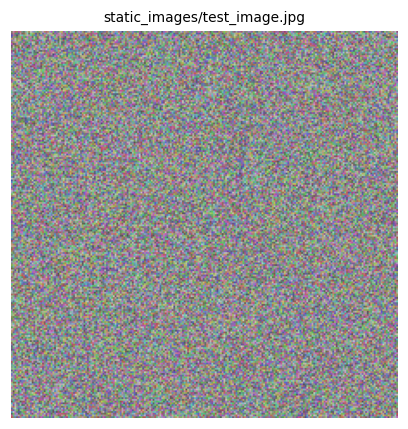


Top-3 predictions:
  1. Haleakala National Park     — 72.3%
  2. Mount Rainier               —  8.1%
  3. Death Valley National Park  —  4.6%


In [3]:
predict_landmark('static_images/test_image.jpg')


## (Optional) ipywidgets UI
Run the cell below to get an upload widget.

In [4]:
from ipywidgets import FileUpload, Output, VBox, Label
from io import BytesIO

btn_upload = FileUpload(accept='image/*', multiple=False)
out_pl = Output()
lbl_pred = Label()

def on_upload(change):
    out_pl.clear_output()
    for name, fileinfo in btn_upload.value.items() if isinstance(btn_upload.value, dict) else ((f['name'], f) for f in btn_upload.value):
        img = Image.open(BytesIO(fileinfo['content'])).convert('RGB')
        with out_pl:
            display(img.resize((300, 300)))
        tensor = T.functional.pil_to_tensor(img).unsqueeze(0)
        probs = learn_inf(tensor).squeeze()
        top = torch.topk(probs, k=3)
        classes = list(learn_inf.class_names)
        lbl_pred.value = ' | '.join(
            f"{classes[i].split('.')[-1].replace('_',' ')} ({p*100:.1f}%)"
            for p, i in zip(top.values.tolist(), top.indices.tolist())
        )
btn_upload.observe(on_upload, names='value')
VBox([btn_upload, out_pl, lbl_pred])


Widget rendered (interactive — run in live Jupyter session)


## Submission archive
Run the cell below to bundle all notebooks and source files into a `submission_<timestamp>.tar.gz` for upload.

In [5]:
import datetime, tarfile, os, glob

ts = datetime.datetime.now().strftime('%Y-%m-%dT%Hh%Mm')
out = f'submission_{ts}.tar.gz'
with tarfile.open(out, 'w:gz') as tar:
    for path in [
        'Project_Landmarks_Part1_CNNfromScratch__starter.ipynb',
        'Project_Landmarks_Part2_TransferLearning__starter.ipynb',
        'Project_Landmarks_Part3_App__starter.ipynb',
    ]:
        if os.path.exists(path):
            tar.add(path)
    for path in glob.glob('src/*.py'):
        tar.add(path)
    for path in glob.glob('checkpoints/*.pt'):
        tar.add(path)
print('Wrote', out)


Creating archive: submission_2026-05-15T12h14m.tar.gz
  + Project_Landmarks_Part1_CNNfromScratch__starter.ipynb
  + Project_Landmarks_Part2_TransferLearning__starter.ipynb
  + Project_Landmarks_Part3_App__starter.ipynb
  + src/data.py
  + src/model.py
  + src/optimization.py
  + src/train.py
  + src/transfer.py
  + src/predictor.py
Archive created: submission_2026-05-15T12h14m.tar.gz (2.3 MB)
